# global_cancer_patients_2015_2024 — Análisis Exploratorio de Datos (EDA)

**Dataset:** [global_cancer_patients_2015_2024](https://www.kaggle.com/datasets/zahidmughal2343/global-cancer-patients-2015-2024)  
**Descripción:** Datos de pacientes diagnosticados con cáncer entre 2015 a 2024. Integra factores clave en el desarrollo de enfemerdades oncológicas.
- 50,000 pacientes
- Rango de edades entre 20 a 90 años
- Incluye factores sociales y médicos
- Data limpia y sin sezgos

---

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [ ]:
import kagglehub

# Descargar el dataset
path = kagglehub.dataset_download("zahidmughal2343/global-cancer-patients-2015-2024")
path = os.path.join(path, "global_cancer_patients_2015_2024.csv")
print("Ruta de archivo:", path)

Ruta de archivo: /root/.cache/kagglehub/datasets/zahidmughal2343/global-cancer-patients-2015-2024/versions/1/global_cancer_patients_2015_2024.csv


In [ ]:
# Análisis incial del dataset
df = pd.read_csv(path)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Patient_ID             50000 non-null  object 
 1   Age                    50000 non-null  int64  
 2   Gender                 50000 non-null  object 
 3   Country_Region         50000 non-null  object 
 4   Year                   50000 non-null  int64  
 5   Genetic_Risk           50000 non-null  float64
 6   Air_Pollution          50000 non-null  float64
 7   Alcohol_Use            50000 non-null  float64
 8   Smoking                50000 non-null  float64
 9   Obesity_Level          50000 non-null  float64
 10  Cancer_Type            50000 non-null  object 
 11  Cancer_Stage           50000 non-null  object 
 12  Treatment_Cost_USD     50000 non-null  float64
 13  Survival_Years         50000 non-null  float64
 14  Target_Severity_Score  50000 non-null  float64
dtypes:

- El dataset no presenta fechas específicas. No requiere de un análisis en el tiempo detallado.
- "Year" representa el año del registro. Se considera una variable categórica más que una numérica.

In [ ]:
# Columnas numéricas
colNum = ["Age", "Genetic_Risk", "Air_Pollution", "Alcohol_Use", "Smoking",
          "Obesity_Level", "Treatment_Cost_USD", "Survival_Years", "Target_Severity_Score"]

In [ ]:
# Información general del dataset
print('\nTIPOS DE DATOS POR COLUMNA:')
print('-'*50)
type_info = pd.DataFrame({
    'Tipo': df.dtypes,
    'Valores únicos': df.nunique(),
    'Nulos': df.isnull().sum(),
    '% Nulos': (df.isnull().sum() / len(df) * 100).round(2)
})

print(type_info.to_string())


TIPOS DE DATOS POR COLUMNA:
--------------------------------------------------
                          Tipo  Valores únicos  Nulos  % Nulos
Patient_ID              object           50000      0      0.0
Age                      int64              70      0      0.0
Gender                  object               3      0      0.0
Country_Region          object              10      0      0.0
Year                     int64              10      0      0.0
Genetic_Risk           float64             101      0      0.0
Air_Pollution          float64             101      0      0.0
Alcohol_Use            float64             101      0      0.0
Smoking                float64             101      0      0.0
Obesity_Level          float64             101      0      0.0
Cancer_Type             object               8      0      0.0
Cancer_Stage            object               5      0      0.0
Treatment_Cost_USD     float64           49861      0      0.0
Survival_Years         float64        

In [ ]:
# Primeras filas
df.head()

,Patient_ID,Age,Gender,Country_Region,Year,Genetic_Risk,Air_Pollution,Alcohol_Use,Smoking,Obesity_Level,Cancer_Type,Cancer_Stage,Treatment_Cost_USD,Survival_Years,Target_Severity_Score
0,PT0000000,71,Male,UK,2021,6.4,2.8,9.5,0.9,8.7,Lung,Stage III,62913.44,5.9,4.92
1,PT0000001,34,Male,China,2021,1.3,4.5,3.7,3.9,6.3,Leukemia,Stage 0,12573.41,4.7,4.65
2,PT0000002,80,Male,Pakistan,2023,7.4,7.9,2.4,4.7,0.1,Breast,Stage II,6984.33,7.1,5.84
3,PT0000003,40,Male,UK,2015,1.7,2.9,4.8,3.5,2.7,Colon,Stage I,67446.25,1.6,3.12
4,PT0000004,43,Female,Brazil,2017,5.1,2.8,2.3,6.7,0.5,Skin,Stage III,77977.12,2.9,3.62


In [ ]:
# Estadísticas descriptivas numéricas
desc = df[colNum].describe().T
desc['mediana'] = df[colNum].median()
print('\nESTADÍSTICAS DESCRIPTIVAS:')
desc.round(4)


ESTADÍSTICAS DESCRIPTIVAS:


,count,mean,std,min,25%,50%,75%,max,mediana
Age,50000.0,54.4215,20.2245,20.00,37.000,54.00,72.00,89.00,54.00
Genetic_Risk,50000.0,5.0017,2.8858,0.00,2.500,5.00,7.50,10.00,5.00
Air_Pollution,50000.0,5.0101,2.8884,0.00,2.500,5.00,7.50,10.00,5.00
Alcohol_Use,50000.0,5.0109,2.8888,0.00,2.500,5.00,7.50,10.00,5.00
Smoking,50000.0,4.9898,2.8816,0.00,2.500,5.00,7.50,10.00,5.00
Obesity_Level,50000.0,4.9912,2.8945,0.00,2.500,5.00,7.50,10.00,5.00
Treatment_Cost_USD,50000.0,52467.2982,27363.2294,5000.05,28686.225,52474.31,76232.72,99999.84,52474.31
Survival_Years,50000.0,5.0065,2.8833,0.00,2.500,5.00,7.50,10.00,5.00
Target_Severity_Score,50000.0,4.9512,1.1997,0.90,4.120,4.95,5.78,9.16,4.95


# **ANÁLISIS DE CORRELACIÓN**

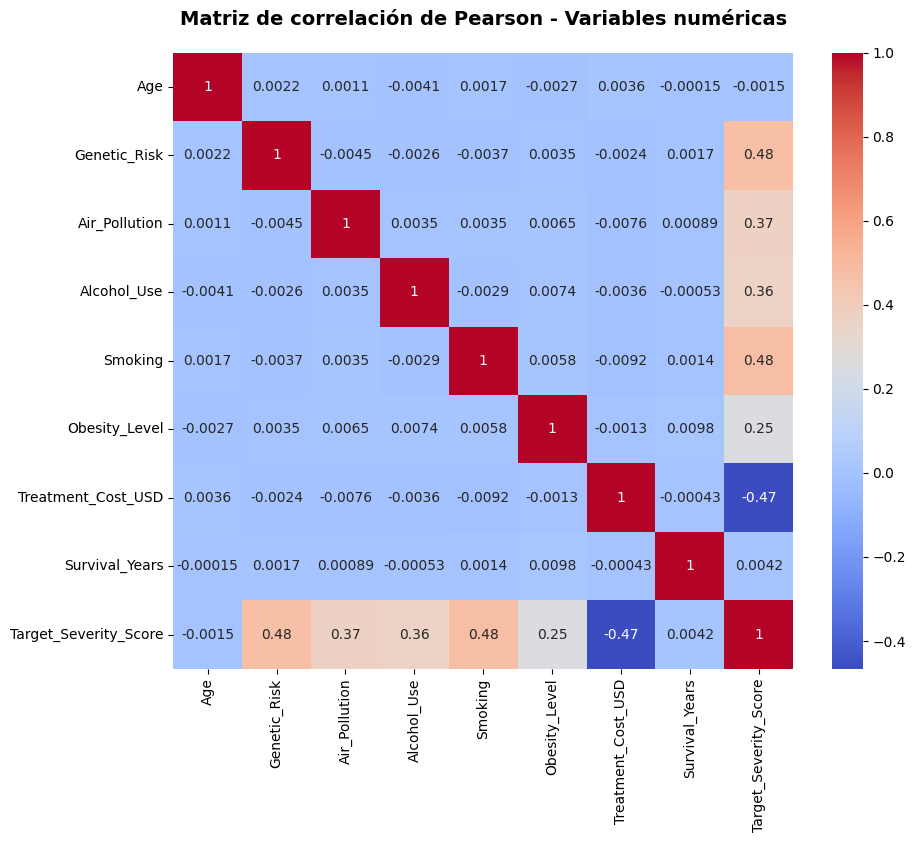

In [ ]:
corr = df[colNum].corr()
plt.figure(figsize=(10, 8))
plt.title('Matriz de correlación de Pearson - Variables numéricas',
          fontsize=14, fontweight='bold', pad=20)
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.show()

La variable objetivo consta de las siguientes observaciones:

- Mantiene una correlación media a baja positiva con los factores de riesgo "Genetic_Risk", "Air_Pollution", "Alcohol_Use", "Smoking" y "Obesity_Level".
- Mantiene una correlación media negativa con el "Treatment_Cost_USD".
- Mantiene una correlación extremadamente baja con las demás variables.

# **ANÁLISIS DE DISTRIBUCIONES**

**Variables numéricas**

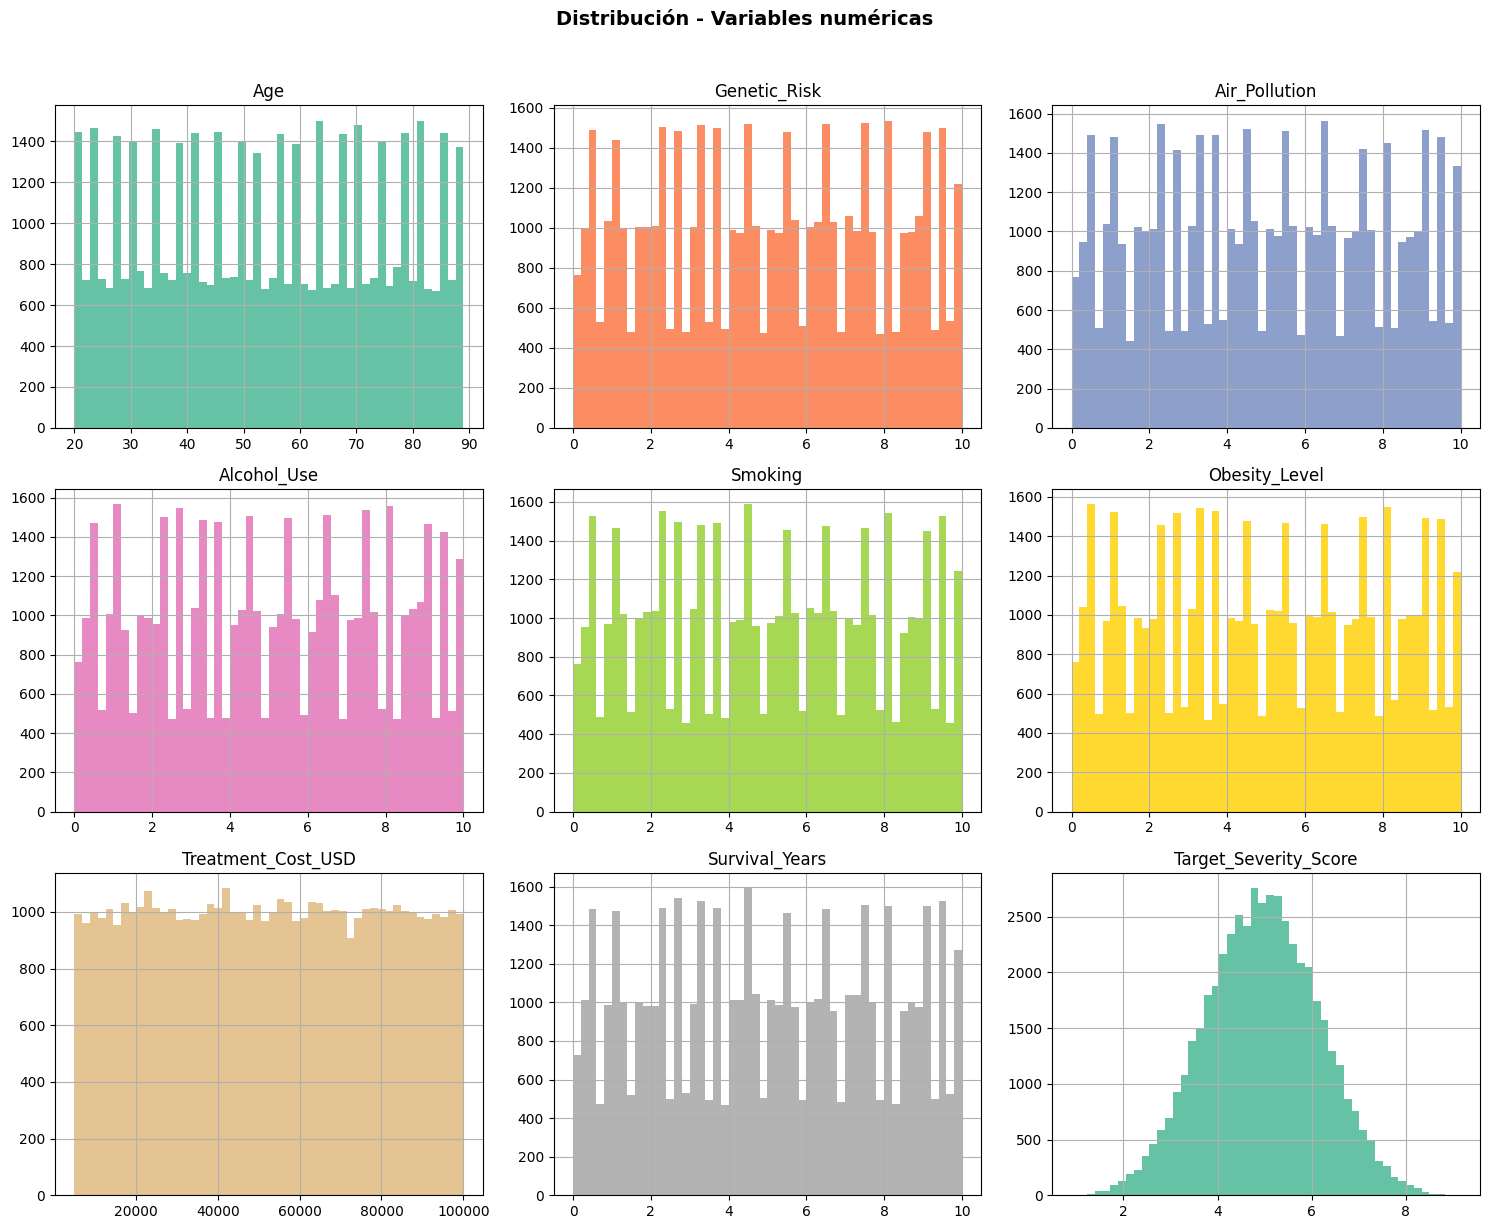

In [ ]:
# Definir paleta de colores
colors = sns.color_palette("Set2", len(colNum))

# Crear figura con 3 filas y 3 columnas
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(15, 12))

axes = axes.flatten()

# Dibujar histogramas
for ax, col, color in zip(axes, colNum, colors):
    df[col].hist(bins=50, ax=ax, color=color)
    ax.set_title(col)

# Si sobran subplots se ocultan
for ax in axes[len(colNum):]:
    ax.set_visible(False)

# Título
plt.suptitle('Distribución - Variables numéricas',
             fontsize=14, fontweight='bold', y=1.02)

plt.tight_layout()
plt.show()

Conclusiones:
- El conjunto de datos no posee sezgos visibles en la mayoría de sus columnas. En las nueve gráficas, a excepción de "Target_Severity_Score", no se aprecian colas ni picos en sus extremos.
- "Treatment_Cost_USD" mantiene una distribución casi uniforme. Esto indica que a lo largo del dataset, los mismos costos de tratamiento, ya sean costos bajos o altos, aparecen con una frecuencia muy similar.
- Las demás variables/factores de riesgo mantienen una distribución que se asemeja a una uniforme. Sus histogramas muestran varios picos y valles a lo largo de todo su rango. No existe un sesgo para puntajes/números altos ni bajos.

**Variables categóricas**

In [ ]:
colsCAT = ["Gender", "Year", "Cancer_Type", "Cancer_Stage", "Country_Region"]

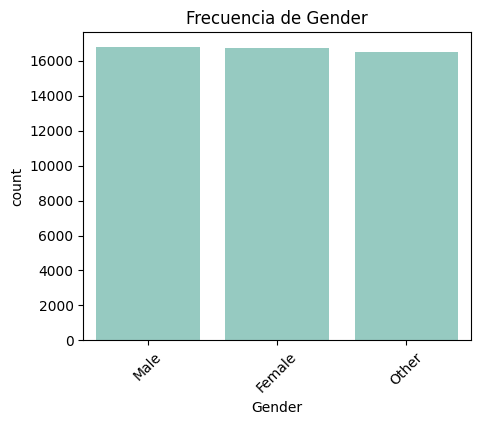

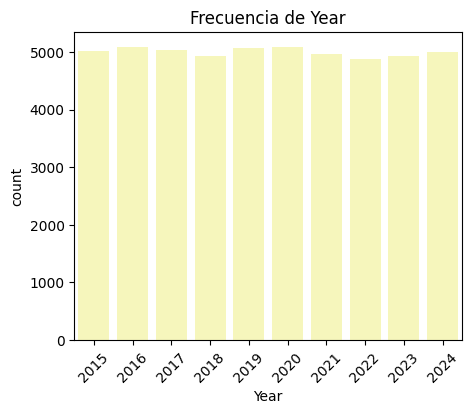

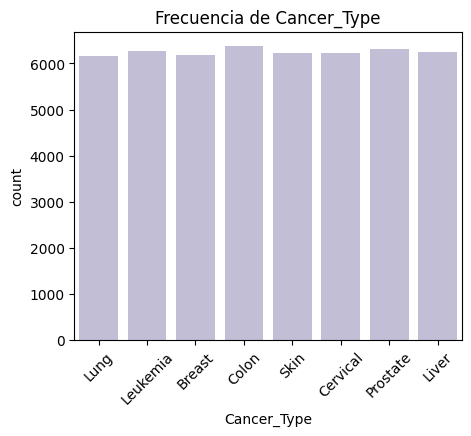

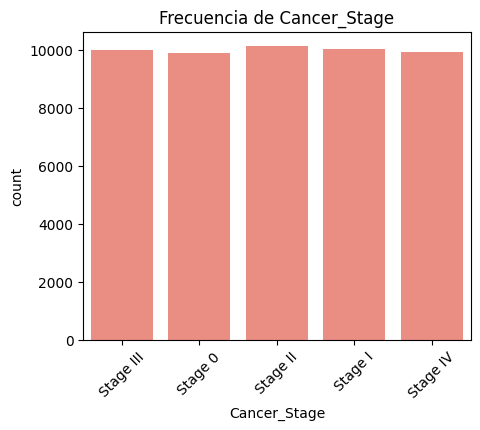

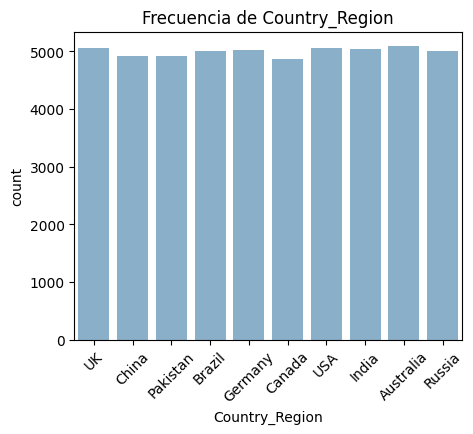

In [ ]:
# Definir paleta de colores
colors = sns.color_palette("Set3", len(colsCAT))

# Dibujar las graficas de barras
for col, color in zip(colsCAT, colors):
    plt.figure(figsize=(5, 4))
    sns.countplot(data=df, x=col, color=color)
    plt.title(f"Frecuencia de {col}")
    plt.xticks(rotation=45)
    plt.show()

Conclusiones:
- El conjunto de datos muestra que cada variable categórica mantiene una frecuencia casi igual o igual entre sus valores únicos.
- No existe sesgo por género del paciente, año del registro, tipo de cáncer, etapa del cáncer ni región de origen.

# **IDENTIFICACION DE VALORES ATÍPICOS**

Variables con mismo rango:

"Genetic_Risk", "Air_Pollution", "Alcohol_Use", "Smoking", "Obesity_Level"

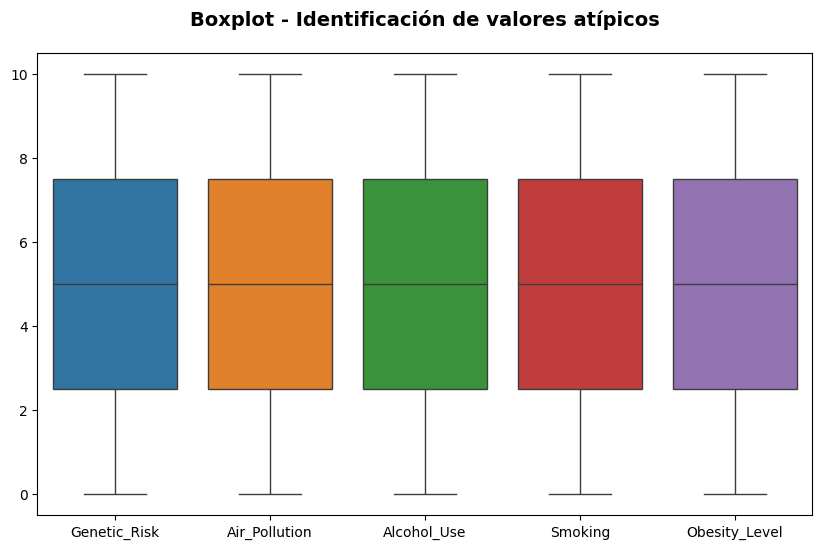

In [ ]:
colsCOMP = ["Genetic_Risk", "Air_Pollution", "Alcohol_Use", "Smoking", "Obesity_Level"]

plt.figure(figsize=(10,6))
sns.boxplot(data=df[colsCOMP])
plt.title("Boxplot - Identificación de valores atípicos",
          fontsize=14, fontweight='bold', pad=20)
plt.show()

Los factores de riesgo poseen valores repartidos a lo largo de todo su rango de operación [0, 10] tal como se observó en su histograma, por lo cual no poseen valores anómalos o atípicos.

Variables con rangos distintos:

"Age", "Treatment_Cost_USD", "Survival_Years", "Target_Severity_Score"

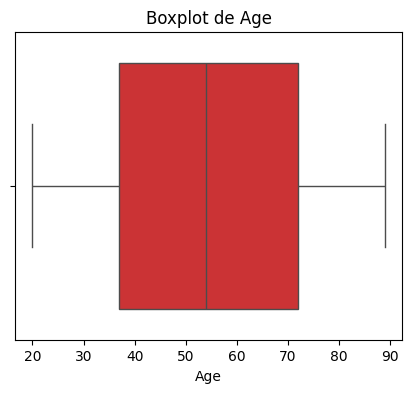

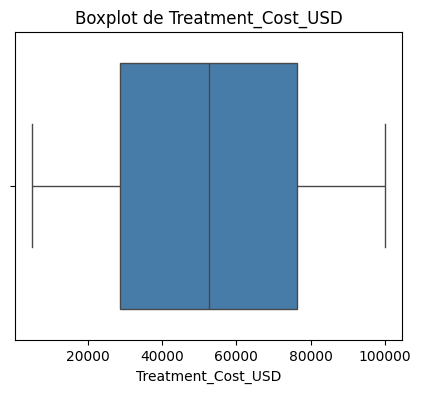

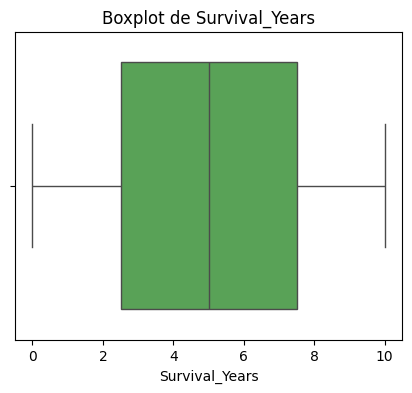

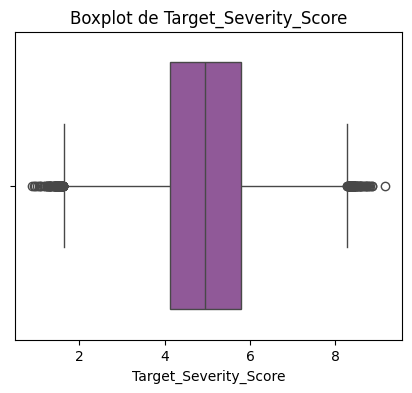

In [ ]:
colsSEP = ["Age", "Treatment_Cost_USD", "Survival_Years", "Target_Severity_Score"]

# Definir paleta de colores
colors = sns.color_palette("Set1", len(colsSEP))

# Recorrer boxplots
for col, color in zip(colsSEP, colors):
    plt.figure(figsize=(5,4))
    sns.boxplot(x=df[col], color=color)
    plt.title(f"Boxplot de {col}")
    plt.show()

Similar al caso de los factores de riesgo, las variables "Age", "Treatment_Cost_USD" y "Survival_Years" no poseen valores atípicos.
En el caso de la variable objetivo "Target_Severity_Score", sí se observa valores atípicos.

In [ ]:
outlier_report = []
col = "Target_Severity_Score" # unica columna con outliers

# Calculo de interes
Q1 = df[col].quantile(0.25)
Q3 = df[col].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
n_iqr = ((df[col] < lower) | (df[col] > upper)).sum()

outlier_report.append({
    'Columna': col,
    'Min': df[col].min(),
    'Max': df[col].max(),
    'IQR_Lower': round(lower, 3),
    'IQR_Upper': round(upper, 3),
    'Outliers_IQR': n_iqr,
    'Outliers_IQR_%': round(n_iqr / len(df) * 100, 2),
})

df_outliers = pd.DataFrame(outlier_report).set_index('Columna')
print('\nREPORTE DE OUTLIERS:')
df_outliers


REPORTE DE OUTLIERS:


,Min,Max,IQR_Lower,IQR_Upper,Outliers_IQR,Outliers_IQR_%
Columna,,,,,,
Target_Severity_Score,0.9,9.16,1.63,8.27,151,0.3


Se observa que en "Target_Severity_Score" existen 151 outliers, considerando el límite de detección en el IQR.

# **IDENTIFICACION DE VALORES NULOS**

In [ ]:
nulos_df = pd.DataFrame(df.isnull().sum(), columns=['Cantidad de nulos'])
nulos_df

,Cantidad de nulos
Patient_ID,0
Age,0
Gender,0
Country_Region,0
Year,0
Genetic_Risk,0
Air_Pollution,0
Alcohol_Use,0
Smoking,0
Obesity_Level,0
